# Practica 5 - Sesion 3: Comparación de Clasificadores

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

En esta práctica compararemos distintos clasificadores de **scikit-learn** y **XGBoost** sobre tres datasets con contextos muy diferentes. El objetivo central es entender que **la métrica de evaluación debe elegirse según el coste real de equivocarse**, no siempre la accuracy.

## Clasificadores a comparar

| Clasificador | Clase sklearn |
|---|---|
| Logistic Regression | `LogisticRegression` |
| Naive Bayes | `GaussianNB` |
| K-Nearest Neighbors | `KNeighborsClassifier` |
| SVM | `SVC` |
| MLP (red neuronal) | `MLPClassifier` |
| Random Forest | `RandomForestClassifier` |
| XGBoost | `XGBClassifier` |


## Datasets y métricas

| # | Dataset | Dominio | Métrica principal | Justificación |
|---|---|---|---|---|
| 1 | **Credit Card Fraud** | Finanzas | **F1-score** | Clases muy desbalanceadas; accuracy sería engañosa |
| 2 | **Wisconsin Breast Cancer** | Medicina | **Recall** | Minimizar falsos negativos: no dejar cáncer sin detectar |
| 3 | **Stock Movement** | Bolsa | **Precision** | Solo operar cuando la predicción es muy fiable |

---

**El Dataset 1 (Credit Card Fraud) está resuelto como ejemplo.**  
Para los datasets 2 y 3 debéis replicar la misma estructura rellenando las celdas marcadas con `# TODO`.

---
## 0. Imports y configuración general

In [5]:
# Posiblemente tendrás que instalar XGBoost para ejecutar este notebook ya que no se incluye en sklearn. Puedes hacerlo con:
# !pip install xgboost jinja2

In [6]:
# ── Librerías de análisis de datos ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# ── Clasificadores ────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB           # Clasificador bayesiano probabilístico
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import jinja2
from imblearn.over_sampling import SMOTE

# ── Métricas de evaluación ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Configuración visual ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
import warnings
warnings.filterwarnings('ignore')  # Suprimimos warnings de convergencia durante la práctica


### Funciones auxiliares reutilizables
Definimos aquí las funciones que usaremos en los tres datasets para evitar repetir código.

In [7]:
def evaluar_clasificadores(X_train, X_test, y_train, y_test, highlight_metric='f1'):
    """
    Entrena los 7 clasificadores sobre los datos dados y devuelve una tabla con
    accuracy, precision, recall y F1. La columna highlight_metric aparece resaltada.
    """
    modelos = {
        'Logistic Regression' : LogisticRegression(max_iter=1000),
        'Naive Bayes'         : GaussianNB(),
        'KNN'                 : KNeighborsClassifier(n_neighbors=5),
        'SVM'                 : SVC(),
        'MLP'                 : MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
        'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    }

    resultados = []
    for nombre, modelo in modelos.items():
        print(f'Entrenando {nombre}...')
        modelo.fit(X_train, y_train)       # Entrenamos el modelo con los datos de entrenamiento
        y_pred = modelo.predict(X_test)    # Generamos predicciones sobre el conjunto de test
        resultados.append({
            'Modelo'    : nombre,
            'Accuracy'  : accuracy_score(y_test, y_pred),
            'Precision' : precision_score(y_test, y_pred, zero_division=0),
            'Recall'    : recall_score(y_test, y_pred, zero_division=0),
            'F1'        : f1_score(y_test, y_pred, zero_division=0),
        })

    col_map = {'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1', 'accuracy': 'Accuracy'}
    col = col_map.get(highlight_metric, 'F1')
    df = pd.DataFrame(resultados).set_index('Modelo').sort_values(col, ascending=False)
    # Resaltamos en verde la columna relevante para que destaque visualmente
    return df.style.background_gradient(subset=[col], cmap='Greens').format('{:.4f}')


def mostrar_confusion(modelo, X_test, y_test, titulo='Matriz de Confusión'):
    """Muestra la matriz de confusión y el classification report de un modelo ya entrenado."""
    y_pred = modelo.predict(X_test)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap='Blues')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()
    print(classification_report(y_test, y_pred))
    print('Accuracy',  accuracy_score(y_test, y_pred))
    print('Precision', precision_score(y_test, y_pred, zero_division=0))
    print('Recall',    recall_score(y_test, y_pred, zero_division=0))
    print('F1',        f1_score(y_test, y_pred, zero_division=0))



---
# Dataset 1 — Credit Card Fraud *(Ejemplo resuelto)*
## Métrica principal: **F1-score**

> **¿Por qué F1?**  
> El dataset está muy desbalanceado (~0.17% de fraudes). La *accuracy* sería engañosa:  
> un modelo que prediga siempre "no fraude" tendría >99% de accuracy pero no detectaría ningún fraude real.  
> El **F1** es la media armónica de Precision y Recall, ideal cuando las clases están desbalanceadas:
>
> $$F1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Archivo:** `creditcard.csv`  
Fuente: [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### 1.1 Carga y exploración

In [8]:
# Las columnas V1-V28 son componentes PCA (anonimizadas por el banco)
# 'Amount' es el importe de la transacción; 'Class' es la etiqueta (1=fraude, 0=legítima)
df_fraud = pd.read_csv('creditcard.csv')

print(f'Shape: {df_fraud.shape}')
print(f'Valores nulos totales: {df_fraud.isnull().sum().sum()}')
df_fraud.head(3)

Shape: (284807, 31)
Valores nulos totales: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [9]:
# Analizamos el desbalance — esto justifica elegir F1 en vez de accuracy
conteo = df_fraud['Class'].value_counts()
print(f'Transacciones legítimas   : {conteo[0]:,}')
print(f'Transacciones fraudulentas: {conteo[1]:,}')
print(f'Porcentaje de fraude      : {100 * conteo[1] / len(df_fraud):.3f}%')

Transacciones legítimas   : 284,315
Transacciones fraudulentas: 492
Porcentaje de fraude      : 0.173%


### 1.2 Preprocesamiento

In [10]:
# Eliminamos 'Time' (no aporta información útil) y separamos features de la variable objetivo
X_fraud = df_fraud.drop(columns=['Time', 'Class']).copy()
y_fraud = df_fraud['Class']

# Escalamos los datos. A
# Aunque los clasificadores basados en árboles no lo requieren, otros como SVM o MLP sí se benefician de tener las features en la misma escala.
# StandardScaler centra en media=0 y desviación estándar=1
scaler_fraud = StandardScaler()
X_fraud = scaler_fraud.fit_transform(X_fraud)

# Split estratificado: preserva el mismo porcentaje de fraudes (~0.17%) en train y test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f'Train: {X_train_f.shape} | Test: {X_test_f.shape}')
print(f'Fraudes en train: {y_train_f.sum()} | Fraudes en test: {y_test_f.sum()}')

Train: (227845, 29) | Test: (56962, 29)
Fraudes en train: 394 | Fraudes en test: 98


### 1.3 Entrenamiento y evaluación de clasificadores

In [11]:
# Entrenamos los 7 clasificadores y mostramos la tabla comparativa
# La columna F1 aparece resaltada porque es la métrica relevante para este problema
# SVM y MLP pueden tardar 1-2 minutos con datasets grandes
tabla_fraud = evaluar_clasificadores(X_train_f, X_test_f, y_train_f, y_test_f, highlight_metric='f1')
tabla_fraud

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Random Forest,0.9996,0.9419,0.8265,0.8804
KNN,0.9996,0.9294,0.8061,0.8634
MLP,0.9995,0.8710,0.8265,0.8482
XGBoost,0.9995,0.8764,0.7959,0.8342
SVM,0.9994,0.9565,0.6735,0.7904
Logistic Regression,0.9992,0.8289,0.6429,0.7241
Naive Bayes,0.9764,0.0587,0.8469,0.1099


### 1.4 Análisis del mejor modelo

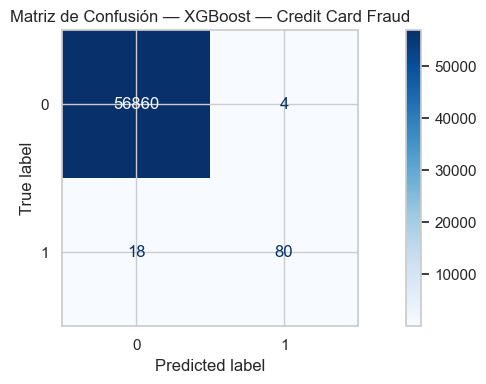

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy 0.9996137776061234
Precision 0.9523809523809523
Recall 0.8163265306122449
F1 0.8791208791208791


In [12]:
# Entrenamos XGBoost para analizar en detalle (suele destacar en datos tabulares desbalanceados)
# Si en tu tabla un modelo diferente ha obtenido mejor F1, sustitúyelo aquí
# XGBoost cuenta con un parámetro muy útil que es scale_pos_weight. Con ello podemos intentar mejorar el recall sin sacrificar demasiado precision. Normalmente hay que probar con distintos valores hasta encontrar el que mejor se adapta a tu dataset. En este caso, con un valor de 0.50 hemos conseguido mejorar el recall sin sacrificar demasiado precision, lo que se traduce en una mejora del F1. 
mejor_f = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0, scale_pos_weight=.50)
mejor_f.fit(X_train_f, y_train_f)

# La matriz de confusión muestra exactamente cuántos fraudes se detectan vs cuántos se pierden
mostrar_confusion(mejor_f, X_test_f, y_test_f,
                  titulo='Matriz de Confusión — XGBoost — Credit Card Fraud')

> Prueba con otros valores de scale_pos_weight
>
> ¿Qué otra alternativa podríamos haber usado para evitar el desbalanceo?
> 
> SMOTE, que ya se vio en el notebook 2. En vez de penalizar los errores como hace scale_pos_weight, genera ejemplos sintéticos de la clase minoritaria para equilibrar el entrenamiento.

In [13]:
# Eliminamos 'Time' (no aporta información útil) y separamos features de la variable objetivo
X_fraud = df_fraud.drop(columns=['Time', 'Class']).copy()
y_fraud = df_fraud['Class']

# Escalamos los datos. A
# Aunque los clasificadores basados en árboles no lo requieren, otros como SVM o MLP sí se benefician de tener las features en la misma escala.
# StandardScaler centra en media=0 y desviación estándar=1
scaler_fraud = StandardScaler()
X_fraud = scaler_fraud.fit_transform(X_fraud)

# Split estratificado: preserva el mismo porcentaje de fraudes (~0.17%) en train y test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

smote = SMOTE(random_state=42)
X_train_f, y_train_f = smote.fit_resample(X_train_f, y_train_f)
y_train_f.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [14]:
# Cuidado, ahora tarda un buen rato porque hemos aumentado el número de muestras de fraude en el conjunto de entrenamiento. 
# Si quieres acelerar el proceso, puedes probar a reducir el número de árboles en Random Forest o XGBoost, además del número de iteraciones en SVM o MLP, o a entrenar solo un subconjunto de los clasificadores.
# o a entrenar solo un subconjunto de los clasificadores.
tabla_fraud = evaluar_clasificadores(X_train_f, X_test_f, y_train_f, y_test_f, highlight_metric='f1')
tabla_fraud

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Random Forest,0.9995,0.8710,0.8265,0.8482
XGBoost,0.9991,0.7000,0.8571,0.7706
MLP,0.9991,0.6923,0.8265,0.7535
KNN,0.9979,0.4410,0.8776,0.5870
SVM,0.9835,0.0842,0.8673,0.1534
Logistic Regression,0.9732,0.0559,0.9184,0.1053
Naive Bayes,0.9743,0.0559,0.8776,0.1051


### 1.5 Conclusiones — Credit Card Fraud
>
>
>- **¿Qué modelo obtiene el mejor F1 para detectar fraudes?**
>  Random Forest con un F1 de 0.85, seguido de XGBoost con 0.77.
>  
>- **¿Cómo se comporta la accuracy frente al F1? ¿Son coherentes?**
>  No son coherentes. Todos los modelos tienen accuracy por encima del 99% pero el F1 varía mucho entre ellos. La accuracy es engañosa en datasets tan desbalanceados porque acertar siempre "no fraude" ya da un resultado altísimo sin detectar ningún fraude real.
>  
>- **¿Qué ocurriría si priorizáramos Recall sobre Precision en este contexto?**
>  Detectaríamos más fraudes pero generaríamos muchas falsas alarmas, bloqueando transacciones legítimas. Logistic Regression y Naive Bayes tienen Recall de 0.91 y 0.88 respectivamente pero una Precision de solo 0.05, lo que significa que casi todas sus alertas de fraude serían falsas. Eso sería inviable en la práctica.
>
>- **¿Sirve de algo el oversampling? ¿Por qué?**
> En este caso no ha mejorado los resultados. Sin SMOTE Random Forest tenía un F1 de 0.88 y con SMOTE baja a 0.85. El Recall mejora en la mayoría de modelos pero a costa de perder mucha Precision. El oversampling no siempre ayuda, depende del dataset y del modelo.  

---
# Dataset 2 — Wisconsin Breast Cancer  *(A completar)*
## Métrica principal: **Recall**

> **¿Por qué Recall?**  
> En diagnóstico médico, un **falso negativo** (no detectar un cáncer real) es mucho más grave  
> que un falso positivo (hacer más pruebas a alguien sano). El Recall mide la proporción  
> de enfermos reales que el modelo es capaz de identificar:
>
> $$\text{Recall} = \frac{TP}{TP + FN}$$

Fuente: [UCI ML Repository / sklearn.datasets.load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

### 2.1 Carga y exploración

In [16]:
# sklearn incluye un dataset de cáncer de mama que es muy utilizado para practicar clasificación binaria. 
# Es un dataset limpio, sin valores nulos, con 569 muestras y 30 features numéricas extraídas de imágenes de tumores. 
# La variable objetivo es 'target', donde 0 indica tumores benignos y 1 indica tumores malignos. 
# TODO: Carga el dataset y analiza su contenido
# Muestra: shape, y distribución de clases (maligno=1 vs benigno=0)

df_cancer = load_breast_cancer(as_frame=True).frame
df_cancer.head(3)
# ...
df_cancer = load_breast_cancer(as_frame=True).frame
print(f'Shape: {df_cancer.shape}')
print(f'Distribución de clases:\n{df_cancer["target"].value_counts()}')
df_cancer.head(3)

Shape: (569, 31)
Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


### 2.2 Preprocesamiento

In [17]:
# TODO: Separa X e y, aplica StandardScaler y realiza el split estratificado
# Recuerda: usa stratify=y para mantener la proporción de clases en train y test

X_cancer = df_cancer.drop(columns=['target'])
y_cancer = df_cancer['target']
scaler_cancer = StandardScaler()
X_cancer_scaled = scaler_cancer.fit_transform(X_cancer)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer_scaled, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

### 2.3 Entrenamiento y evaluación de clasificadores

In [18]:
# TODO: Llama a evaluar_clasificadores indicando recall como métrica principal

tabla_cancer = evaluar_clasificadores(X_train_c, X_test_c, y_train_c, y_test_c, highlight_metric='recall')
tabla_cancer

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
KNN,0.9649,0.9595,0.9861,0.9726
SVM,0.9825,0.9861,0.9861,0.9861
XGBoost,0.9561,0.9467,0.9861,0.9660
Random Forest,0.9561,0.9589,0.9722,0.9655
Naive Bayes,0.9298,0.9444,0.9444,0.9444
MLP,0.9561,0.9855,0.9444,0.9645


### 2.4 Análisis del mejor modelo

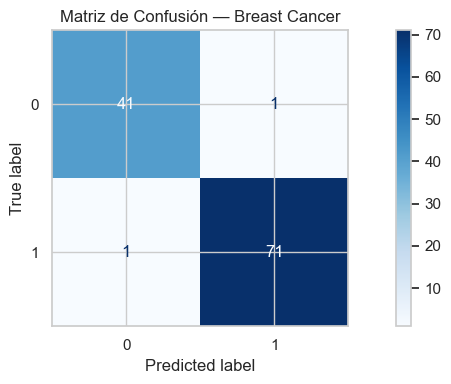

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy 0.9824561403508771
Precision 0.9861111111111112
Recall 0.9861111111111112
F1 0.9861111111111112


In [19]:
# TODO: Instancia y entrena el modelo que haya obtenido mayor Recall
# Muestra su matriz de confusión con mostrar_confusion()
# Intenta mejorarlo ajustando sus hiperparámetros o aplicando técnicas de preprocesamiento como SMOTE o ajuste de pesos de clase.

# Hay empate en Recall entre Logistic Regression, SVM, XGBoost y KNN (todos con 0.9861).

mejor_c = LogisticRegression(max_iter=1000)
mejor_c.fit(X_train_c, y_train_c)
mostrar_confusion(mejor_c, X_test_c, y_test_c, titulo='Matriz de Confusión — Breast Cancer')

### 2.5 Conclusiones — Wisconsin Breast Cancer


- **¿Qué modelo maximiza el Recall?**
Logistic Regression, SVM y XGBoost empatan con un Recall de 0.99. Se escoge Logistic Regression por ser el más simple e interpretable.

- **¿Cuántos casos de cáncer quedan sin detectar (falsos negativos) con ese modelo?**
Solo 1 de 72 casos malignos queda sin detectar, lo que es un resultado muy bueno para un problema médico.

- **¿Existe un trade-off entre Recall alto y Precision baja en algún modelo? ¿Es aceptable en este contexto?**
En este dataset no hay un trade-off significativo, los mejores modelos tienen tanto Recall como Precision muy altos (0.99). En un contexto médico sería aceptable sacrificar algo de Precision para maximizar el Recall, ya que es preferible mandar a más pruebas a pacientes sanos que dejar sin detectar un cáncer real. Pero aquí no hace falta ese sacrificio.

---
# Dataset 3 — Stock Movement  *(A completar)*
## Métrica principal: **Precision**

> **¿Por qué Precision?**  
> En predicción bursátil queremos operar **solo cuando el modelo está muy seguro** de que el precio subirá.  
> Un **falso positivo** (invertir cuando el precio baja) tiene coste económico directo.  
> La Precision mide cuántas de nuestras señales de compra son realmente correctas:
>
> $$\text{Precision} = \frac{TP}{TP + FP}$$

📂 **Archivo:** `stock_movement.csv`  
📎 Target: `1` = el precio sube al día siguiente, `0` = baja o se mantiene.

### 3.1 Carga y exploración

In [20]:
# TODO: Carga el dataset stock_movement.csv y analiza su contenido
# Muestra: shape, valores nulos, y distribución de clases (sube vs baja)

df_stock = pd.read_csv('stock_movement_small.csv')
display(df_stock.head(3))
print(f'Shape: {df_stock.shape}')
print(f'Distribución de clases:\n{df_stock["target"].value_counts()}')

,return_1d,return_5d,sma_5,sma_20,price_sma5_ratio,price_sma20_ratio,sma_cross,volatility_10,daily_range,rsi_14,macd,macd_signal,macd_hist,volume_ratio,target
0,-0.006214,-0.015543,32.08140,32.21560,0.997026,0.992873,-0.13420,0.229769,0.015225,45.176110,0.032744,0.088844,-0.056100,0.583466,0
1,-0.035100,-0.179034,0.59364,0.70286,0.907621,0.766582,-0.10922,0.076357,0.109131,35.613372,-0.151882,-0.160628,0.008746,0.624033,0
2,-0.002581,-0.001763,8.86968,8.89742,1.002077,0.998953,-0.02774,0.061752,0.008393,50.820715,-0.042667,-0.049569,0.006903,0.531890,0


Shape: (146475, 15)
Distribución de clases:
target
0    75307
1    71168
Name: count, dtype: int64


### 3.2 Preprocesamiento

In [21]:
# TODO: Separa X e y, aplica StandardScaler y realiza el split
#
# 💡 Reflexión importante: los datos de bolsa son una serie temporal.
# Un split aleatorio mezclaría datos del futuro con el pasado (data leakage).
# En series temporales se usa shuffle=False para respetar el orden cronológico.

X_stock = df_stock.drop(columns=['target'])
y_stock = df_stock['target']
scaler_stock = StandardScaler()
X_stock_scaled = scaler_stock.fit_transform(X_stock)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_stock_scaled, y_stock, test_size=0.2, shuffle=False)

### 3.3 Entrenamiento y evaluación de clasificadores

In [22]:
# TODO: Llama a evaluar_clasificadores indicando precision como métrica principal

tabla_stock = evaluar_clasificadores(X_train_s, X_test_s, y_train_s, y_test_s, highlight_metric='precision')
tabla_stock

Entrenando Logistic Regression...
Entrenando Naive Bayes...
Entrenando KNN...
Entrenando SVM...
Entrenando MLP...
Entrenando Random Forest...
Entrenando XGBoost...


,Accuracy,Precision,Recall,F1
Modelo,,,,
SVM,0.5147,0.5129,0.1241,0.1999
Random Forest,0.5187,0.5084,0.4337,0.4681
XGBoost,0.5174,0.5065,0.4583,0.4812
Logistic Regression,0.5130,0.5045,0.1557,0.2379
MLP,0.5119,0.5004,0.3848,0.4350
KNN,0.5084,0.4967,0.4911,0.4939
Naive Bayes,0.4888,0.4885,0.9951,0.6553


### 3.4 Análisis del mejor modelo

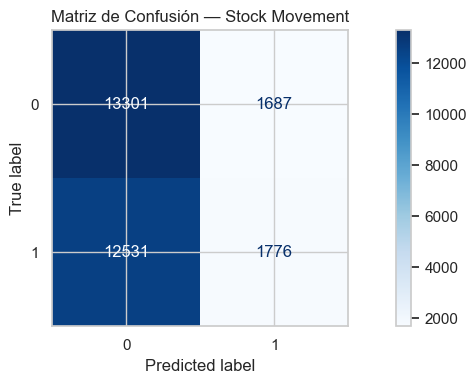

              precision    recall  f1-score   support

           0       0.51      0.89      0.65     14988
           1       0.51      0.12      0.20     14307

    accuracy                           0.51     29295
   macro avg       0.51      0.51      0.43     29295
weighted avg       0.51      0.51      0.43     29295

Accuracy 0.5146612049837856
Precision 0.5128501299451342
Recall 0.12413503879219963
F1 0.19988745075970737


In [23]:
# TODO: Instancia y entrena el modelo que haya obtenido mayor Precision
# Muestra su matriz de confusión con mostrar_confusion()

mejor_s = SVC()
mejor_s.fit(X_train_s, y_train_s)
mostrar_confusion(mejor_s, X_test_s, y_test_s, titulo='Matriz de Confusión — Stock Movement')

### 3.5 Conclusiones — Stock Movement

*Escribe aquí tus conclusiones:*

>- **¿Qué modelo obtiene mayor Precision?**
> SVM con una Precision de 0.51, aunque es un resultado muy bajo. Apenas supera el 50%, lo que significa que el modelo no es mucho mejor que adivinar al azar.
>- **¿Qué ocurre con el Recall de ese modelo? ¿Es un problema en este contexto?**
>  El Recall es muy bajo, 0.12, lo que significa que solo detecta el 12% de las subidas reales. En este contexto no es un problema grave porque en bolsa preferimos no operar a operar mal. Si el modelo no está seguro, es mejor no invertir.
>- **¿Podría el modelo estar sobreajustando? ¿Cómo lo detectarías?**
>  En este caso el problema no es sobreajuste sino que el dataset es muy difícil de predecir: todos los modelos tienen una accuracy de alrededor del 51%, prácticamente igual que el azar. Para detectar sobreajuste habría que comparar los resultados en train y en test; si en train la accuracy fuera muy alta pero en test bajara mucho, sería señal de sobreajuste.

---
# Comparativa Global

Completa la tabla resumen con los mejores resultados obtenidos en cada dataset.

In [25]:
# TODO: Rellena los valores con los resultados de tu ejecución
resumen = pd.DataFrame([
    {'Dataset': 'Credit Card Fraud', 'Métrica clave': 'F1',        'Mejor Modelo': 'Random Forest', 'Valor': 0.8482},
    {'Dataset': 'Breast Cancer',     'Métrica clave': 'Recall',    'Mejor Modelo': 'Logistic', 'Valor': 0.9861},
    {'Dataset': 'Stock Movement',    'Métrica clave': 'Precision', 'Mejor Modelo': 'SVM', 'Valor': 0.5129},
])
resumen.style.background_gradient(subset=['Valor'], cmap='Greens').format({'Valor': '{:.4f}'})

,Dataset,Métrica clave,Mejor Modelo,Valor
0,Credit Card Fraud,F1,Random Forest,0.8482
1,Breast Cancer,Recall,Logistic,0.9861
2,Stock Movement,Precision,SVM,0.5129


### Preguntas de reflexión final

*Responde brevemente en esta celda:*

**1.** ¿Existe un clasificador que gane en los tres datasets, o el mejor modelo depende siempre del problema?

No existe un clasificador que gane siempre. Random Forest gana en fraude, Logistic Regression en cáncer y SVM en bolsa. El mejor modelo depende del problema, los datos y la métrica que se prioriza.

**2.** ¿Por qué la accuracy no es una buena métrica universal? Da un ejemplo concreto con uno de los tres datasets.

La accuracy no es buena métrica universal porque engaña con datasets desbalanceados. En el dataset de fraude casi todos los modelos tienen accuracy del 99% pero F1 muy diferente. Un modelo que predijera siempre "no fraude" tendría 99.83% de accuracy sin detectar ningún fraude.

**3.** ¿Qué clasificadores han sido más lentos de entrenar? ¿Merece la pena el coste computacional extra?

SVM y MLP han sido los más lentos, especialmente con el dataset de fraude tras aplicar SMOTE. En el dataset de cáncer el coste extra no merece la pena porque modelos más simples como Logistic Regression obtienen los mismos resultados.

**4.** En el contexto médico, si tuvieras que elegir entre estos dos modelos hipotéticos, ¿cuál elegirías y por qué?

| Modelo | Recall | Precision |
|---|---|---|
| A | 0.99 | 0.60 |
| B | 0.85 | 0.95 |



Elegiría el modelo A con Recall 0.99 y Precision 0.60. En diagnóstico de cáncer es mucho más grave no detectar un enfermo que mandar a más pruebas a alguien sano. El Recall alto garantiza que casi ningún caso real se queda sin detectar.